In [ ]:
import numpy as np
import cabinetry
import json
import pyhf
import matplotlib.pyplot as plt
import matplotlib as mpl
import glob
import uproot
from copy import deepcopy
from functools import partial
import time
from multiprocessing import Pool 
from tqdm import tqdm

# 🗄️🗄️🗄️🗄️ Counting example

Lets use the following setup:

- Counting experiment, 1 bin
- 4 background events expected ± X
- 4 events observed ± 2
- 1 signal event expected ± 0



In [ ]:
S1 = {"variable": [1]*np.ones(100), "weights" : [0.01]*np.ones(100)}
B1 = {"variable": [1]*np.ones(4), "weights" : [1]*np.ones(4)}
D1 = {"variable": [1]*np.ones(4), "weights" : [1]*np.ones(4)}

We will ulilize the branch from the following cabinetry PR:
https://github.com/scikit-hep/cabinetry/pull/516/

In [ ]:
def write_root_with_uproot(path, treename, data_like):

    if isinstance(data_like, dict):
        arrays = {k: np.asarray(v) for k, v in data_like.items()}
    elif isinstance(data_like, np.ndarray) and data_like.dtype.names:
        arrays = {name: data_like[name] for name in data_like.dtype.names}
    else:
        raise TypeError("what")
    with uproot.recreate(path) as f:
        f[treename] = arrays

write_root_with_uproot("./data1.root", "pseudodata", D1)
write_root_with_uproot("./signal1.root", "signal", S1)
write_root_with_uproot("./background1.root", "background", B1)

In [ ]:
config = {
   "General":{
      "Measurement": "None",
      "POI": r"$\mu$",              # parameter of interest, which we want to measure 
      "InputPath": "./{SamplePath}", # where to find input data
      "HistogramFolder": "histograms/"
   }
}

In [ ]:
binning = list(np.linspace(0, 1.0000000000001, 2))
config.update({
    "Regions":[
        {
            "Name": r"counting",
            "Filter": f"variable==variable",    # event selection 
            "Variable": "variable",      
            "Binning": binning
        },
   ]
})

In [ ]:
config.update({
   "Samples":[
      {
         "Name": "pseudodata",
         "Tree": "pseudodata",
         "SamplePath": "data1.root", # this is Asimov dataset with no signal expected
         "Data": True,               # observed data is handled differently, need to distinguish
         "Weight": "weights"
      },
      {
         "Name": "signal",
         "Tree": "signal",
         "SamplePath": "signal1.root", 
         "Weight": "weights",
         "DisableStaterror": True # for simplicity of the excercise; very small if signal MC with high number of events is generated
      },
      {
         "Name": "background",
         "Tree": "background",
         "SamplePath": "background1.root",
         "Weight": "weights",
         "DisableStaterror": False
      },
   ]
})

In [ ]:
config.update({"Systematics": []})

config.update({
   "NormFactors":[ # Normfactor is unconstrained parameter
      {
         "Name": r"$\mu$", # The name of this parameter of interest (POI)
         "Samples": "signal", # Sample, to which unconstrained normalization is applied
         "Nominal": 0.0, 
         "Bounds": [-100, +100]
      }
   ]
})

In [ ]:
config.update({
    "Systematics":[
        {
            "Name": "sqrt4 shapesys",
            "Up": {"Weight": "weights*(1.5)"},
            "Down": {"Weight": "weights*(0.5)"},
            "Samples": [
                "background",
            ],
            "Regions": [
                "counting",
            ],
             "Type": "NormPlusShape"
        },                
#         {
#             "Name": "Normaliz",
#             "Up": {"Normalization": +0.5},
#             "Down": {"Normalization": -0.5},
#             "Samples": [
#                 "background",
#             ],
#             "Regions": [
#                 "counting",
#             ],
#             "Type": "Normalization"
#         },
        {
            "Name": "sqrt4 normsys",
            "Up": {"Weight": "weights*(1.5)"},
            "Down": {"Weight": "weights*(0.5)"},
            "Samples": [
                "background",
            ],
            "Regions": [
                "counting",
            ],
             "Type": "NormPlusShape"
        },  
        {
            "Name": "sqrt4 histosys",
            "Up": {"Weight": "weights*(1.5)"},
            "Down": {"Weight": "weights*(0.5)"},
            "Samples": [
                "background",
            ],
            "Regions": [
                "counting",
            ],
             "Type": "NormPlusShape"
        },
    ],
})


In [ ]:
cabinetry.configuration.validate(config)

In [ ]:
cabinetry.configuration.print_overview(config)

cabinetry.templates.build(config, method="uproot")

cabinetry.templates.postprocess(config)

In [ ]:
fig = cabinetry.visualize.data_mc_from_histograms(config, colors =  {"signal":"red", "background":"lightgrey"})
fig[0]['figure'].get_axes()[0].set_ylim(0,10) #4.5
fig[0]['figure'].get_axes()[0].set_xlim(-0.1,2)
fig[0]['figure'].get_axes()[1].set_xlim(-0.1,2)
fig[0]['figure'].get_axes()[1].set_ylim(-0.25,2.25)
fig[0]['figure'].get_axes()[1].set_yticks([0,0.5,1,1.5,2], labels = [0,0.5,1,1.5,2])
fig[0]['figure'].get_axes()[1].minorticks_off()

In [ ]:
_ = cabinetry.visualize.templates(config)

In [ ]:
workspace_path = "json/counting_workspace.json"
spec = cabinetry.workspace.build(config)

In [ ]:
spec

We have created a model specification with the tools provided by cabinetry.

We can patch it a bit to make a more inclusive example.

In [ ]:
### replace normsys with histosys
for channel in spec["channels"]:
        for sample in channel["samples"]:      
            ns = next(
                (
                    mod
                    for mod in sample["modifiers"]
                    if  mod["type"] == "normsys" and mod["name"] == "sqrt4 histosys"
                ),
                None,
            )

            if ns:        
                if sample["name"] == "background":
                    norm_up, norm_down = ns["data"]["hi"], ns["data"]["lo"]
                    sample["modifiers"].remove(ns)
        
                    hs_up = np.asarray(sample["data"]) * norm_up
                    hs_dn = np.asarray(sample["data"]) * norm_down
                
                    histosys_modifier = {
                    "data": {"hi_data": hs_up.tolist(),
                             "lo_data": hs_dn.tolist(),},
                    "name": "sqrt4 histosys",
                    "type": "histosys",
                    }
                    sample["modifiers"].append(histosys_modifier)

In [ ]:
def shapesystemize(name_to_decorrelate, spec, vetosamples=[], vetocats=[]):

    for channel in spec["channels"]:
        for sample in channel["samples"]:
            if sample["name"] in vetosamples:
                continue  # veto samples as needed
            if channel["name"] in vetocats:
                continue  # veto channels

            # find the normsys and histosys modifiers
            normsys = next(
                (
                    mod
                    for mod in sample["modifiers"]
                    if mod["name"] == name_to_decorrelate and mod["type"] == "normsys"
                ),
                None,
            )
            histosys = next(
                (
                    mod
                    for mod in sample["modifiers"]
                    if mod["name"] == name_to_decorrelate and mod["type"] == "histosys"
                ),
                None,
            )

            if normsys:
                norm_up, norm_down = normsys["data"]["hi"], normsys["data"]["lo"]
                sample["modifiers"].remove(normsys)  # delete the existing modifier
            else:
                norm_up, norm_down = 1.0, 1.0

            if histosys:
                # symmetrize
                shapesys_up = np.asarray(histosys["data"]["hi_data"]) * norm_up
                shapesys_down = np.asarray(histosys["data"]["lo_data"]) * norm_down
                shapesys_data = np.abs(shapesys_up - shapesys_down) / 2
                sample["modifiers"].remove(histosys)  # delete the existing modifier
            else:
                shapesys_data = np.asarray(sample["data"]) * abs(norm_up - norm_down) / 2

            shapesys_modifier = {
                "data": shapesys_data.tolist(),
                "name": f"{name_to_decorrelate}",
                "type": "shapesys",
            }
            sample["modifiers"].append(shapesys_modifier)

In [ ]:
### replace normsys with shapesys
shapesystemize("sqrt4 shapesys", spec, vetosamples = "signal")

In [ ]:
### rename staterror
for channel in spec["channels"]:
        for sample in channel["samples"]:      
            staterr = next(
                (
                    mod
                    for mod in sample["modifiers"]
                    if  mod["type"] == "staterror"
                ),
                None,
            )

            if staterr:
                # print(staterr["name"])
                staterr["name"] = "sqrt4 staterror"

In [ ]:
cabinetry.workspace.save(spec, workspace_path)

In [ ]:
c = cabinetry.visualize.modifier_grid(pyhf.Workspace(spec).model(),close_figure=False)
locs, labels = plt.xticks()
ll =[]
for i in range(len(labels)):
        ll.append(fr'{labels[i].get_text()}')      
plt.xticks(locs, ll, rotation='vertical', horizontalalignment='center')


c.set_figwidth(c.get_figwidth()*2.1)
c.set_figheight(c.get_figheight()*2.1) 

In [ ]:
spec

So this is our specification of the model.

It holds all of our channels, samples, modifiers etc.

In [ ]:
for channel in spec['channels']:
    print(channel['name'])

In [ ]:
for channel in spec['channels']:
    for sample in channel['samples']:
        print(sample['name'])

In [ ]:
for channel in spec['channels']:
    for sample in channel['samples']:
        for mod in sample['modifiers']:
            print(mod['name'])
        

In [ ]:
for channel in spec['channels']:
    print(f"Channel: {channel['name']}")
    
    for sample in channel['samples']:
        print(f" Sample: {sample['name']}")
        
        for mod in sample['modifiers']:
            print(f"  Parameter: {mod['name']}")
        

But how does the likelihood look like?

[pyhf docs](https://pyhf.readthedocs.io/en/v0.7.6/intro.html)
 have this "scary" description:

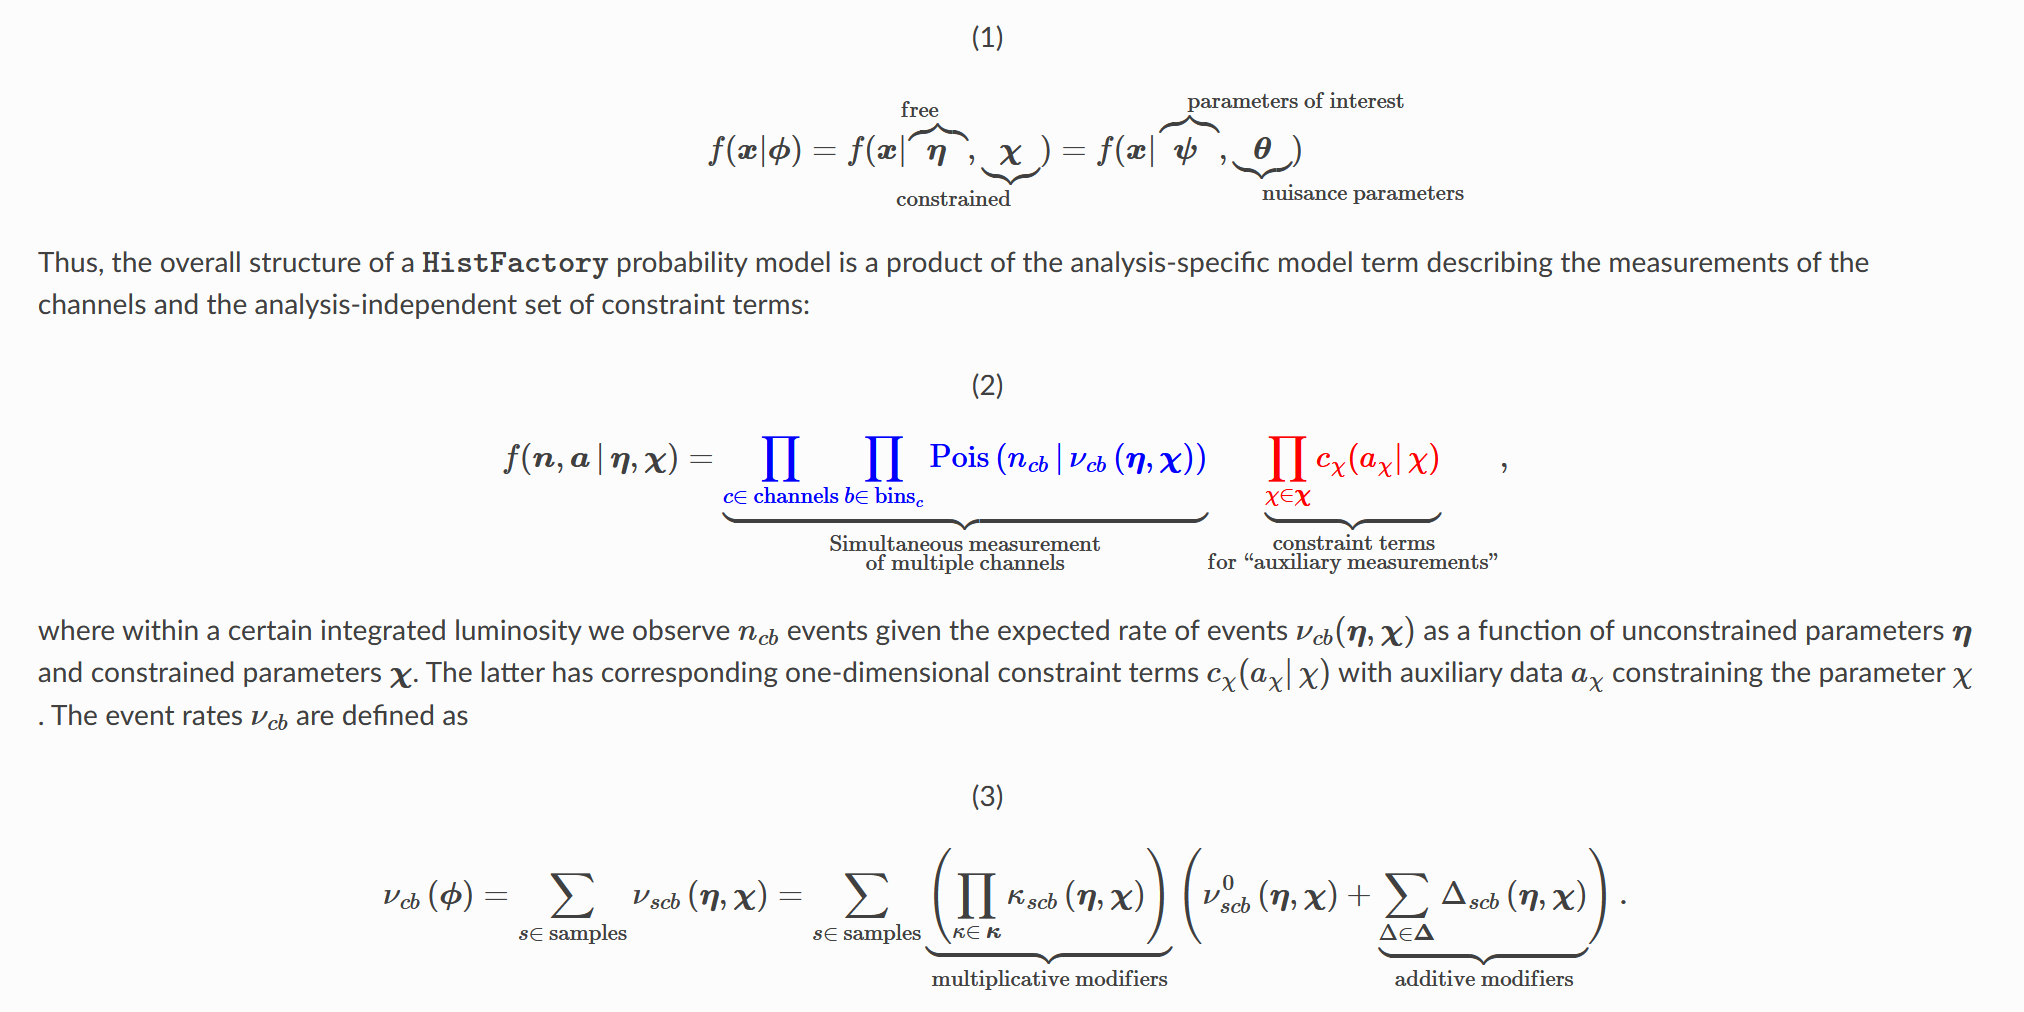

For our model we can simplify the expression of the likelihood as such:

$\mathcal{L}(\mu| \vec{\chi})  =  Pois(n^{obs}|\nu^{exp}(\vec{\chi})) \prod_{\chi \in \vec{\chi}} c_{\chi}(a_\chi|\chi)$

Here, the $n^{obs}$ is the number of observed events, while the expected value is denoted by $\nu^{exp}$.

The systematic uncertainties are included into the likelihood through a set of nuisance parameters $\vec{\chi}$, which are event count modifiers constrained by normal probability functions $c_{\chi}$. 

Each constraint is linked to auxiliary data $a_{\chi}$. 

Lets check all the building blocks separately:

In [ ]:
def remove_modtypes(sp: dict, remove_types: set):
    for ch in sp.get("channels", []):
        for s in ch.get("samples", []):
            mods = s.get("modifiers", [])
            s["modifiers"] = [m for m in mods if m.get("type") not in remove_types]

In [ ]:
minispec = [deepcopy(spec) for _ in range(5)]

# 0) staterror only
remove_modtypes(minispec[0], { "normsys", "histosys", "shapesys"})

# 1) normsys only
remove_modtypes(minispec[1], {"staterror",  "histosys", "shapesys"})

# 2) histosys only
remove_modtypes(minispec[2], {"staterror", "normsys",  "shapesys"})

# 3) shapesys only
remove_modtypes(minispec[3], {"staterror", "normsys", "histosys", })

# 4) no systematics (remove all four types)
remove_modtypes(minispec[4], {"staterror", "normsys", "histosys", "shapesys"})

In [ ]:
for i in range(5):
    print(minispec[i])
    print("--------")

In [ ]:
# fit with no systematics, just the data uncertainty
model, data = cabinetry.model_utils.model_and_data(minispec[4])
fit_results = cabinetry.fit.fit(model, data)
for label, result, unc in zip(fit_results.labels, fit_results.bestfit, fit_results.uncertainty):
    print(f"{label}: {result:.3f} +/- {unc:.3f}")

- Fit with no Nuisance Parameters (NP)
- No uncertainties on the templates
- Data uncertainty from 4 observed events is 2 (Poisson)
- Data uncertainty translates to POI uncertainty of 2.
  
Makes total sense, right? 

So how does it now change with the inclusion of different systematics?

#### <span style="color: orange;">Staterror</span>

- Gaussian uncertainty on bin yield $N(1,\sigma)$ with $\sigma= \frac{\sqrt{MC \; bin \; yield}}{MC \; bin \; yield}$
- Unweighted case:
    - Think MC $\int L$ = data $\int L$ 


#### <span style="color: blue;">Normsys</span>

- Gaussian-driven overall scaling uncertainty 
- $N ( bin \; yield, \sqrt{bin \; yield} ) \times f$
    - Where $f$ is an interpolation function


#### <span style="color: green;">Histosys</span>

- Gaussian-constrained additive uncertainty
    - This case: $\Delta = \pm 2$  

#### <span style="color: purple;">Shapesys</span>

- Poisson uncertainty on MC bin yield
    - $\sigma= \sqrt{MC \; bin \; yield}$


### We will assign these uncertainties to our backgrounds one by one

In [ ]:
slist = ["staterror", "normsys", "histosys", "shapesys"]
for i, sy in  enumerate(slist):
    print(f"{sy} - only fit:")
    model, data = cabinetry.model_utils.model_and_data(minispec[i])
    fit_results = cabinetry.fit.fit(model, data)
    for label, result, unc in zip(fit_results.labels, fit_results.bestfit, fit_results.uncertainty):
        print(f"{label}: {result:.3f} +/- {unc:.3f}")
    print("-------")

So, do these numbers make sense?
We know that uncertainty on POI from data is 2.
We have plugged in uncertainties of a size of sqrt(4).

The naively expected uncertainty should be:

In [ ]:
np.sqrt(2**2+2**2)

<details>
  <summary>Spoiler warning</summary>
  
In one case the uncertainty on POI is not like in the rest, right?

And it does not quite match the uncertainty estimated by an educated guess.

So why does it happen?
  
</details>

In [ ]:
for i, sy in  enumerate(slist):
    model, data = cabinetry.model_utils.model_and_data(minispec[i])
    
    li1 = []
    li2 = []
    xran = np.arange(-4.5, 4.5, 4.5/1000)

    if model.config.poi_index ==0:
        order = 0
    else:
        order = 1
    
    for nu in xran:
        if order == 0:
            parr = [0,nu]
        else:
            parr = [nu,0]
        li1.append(-model.logpdf(pars=parr, data=data))
        li2.append(-model.constraint_logpdf(auxdata = np.array(model.config.auxdata), pars = np.array(parr)))
        
    fig, ax = plt.subplots(layout="constrained", figsize=(4*1.71875, 4))
    ax.plot(xran, li1, "-", color="black", label=f"model.logpdf, {sy}")
    ax.plot(xran, li2, "--", color="black", label=f"model.constraint_logpdf, {sy}")

    plt.legend()
    ax.set_xlabel("auxdata value")
    ax.set_ylabel("-log L")


All of these run different logic under the hood

[pyhf docs](https://pyhf.readthedocs.io/en/v0.7.6/intro.html)


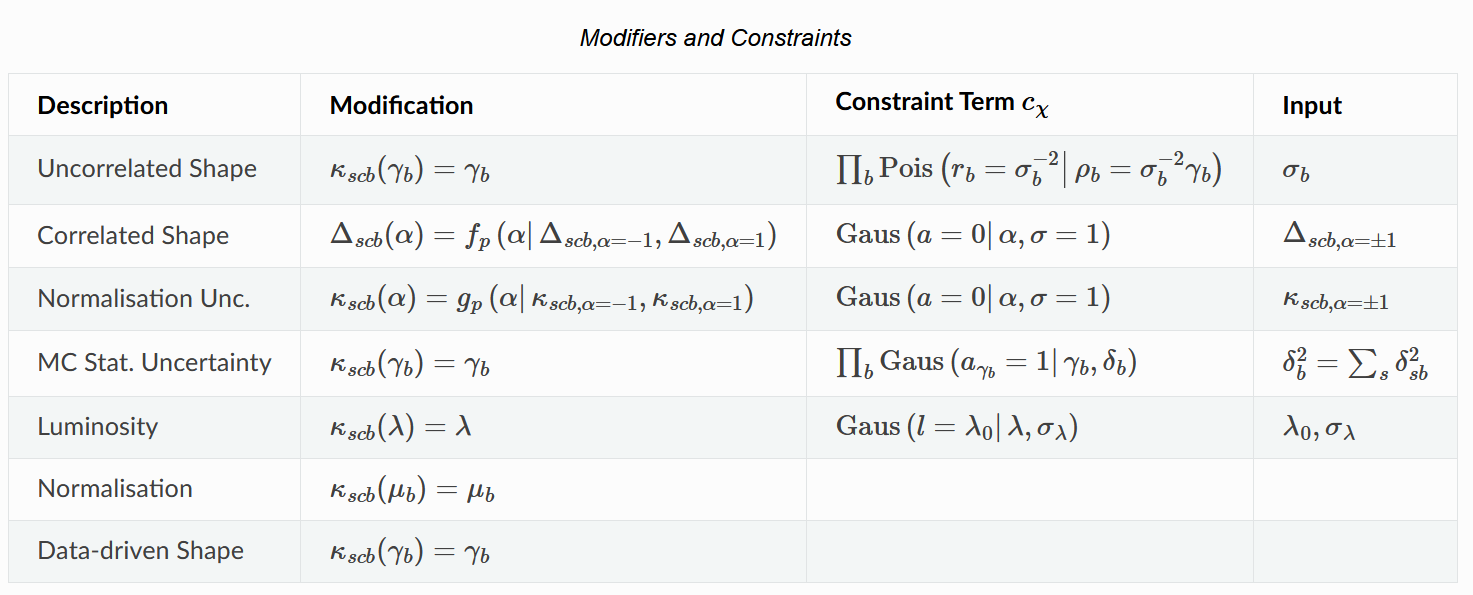

The interpolation function of the normsys modifier ensures the bin yield never goes to zero. -> this distorts likelihood and therefore uncertainty on POI

From [HistFactory](https://cds.cern.ch/record/1456844/files/CERN-OPEN-2012-016.pdf?version=1) paper: 
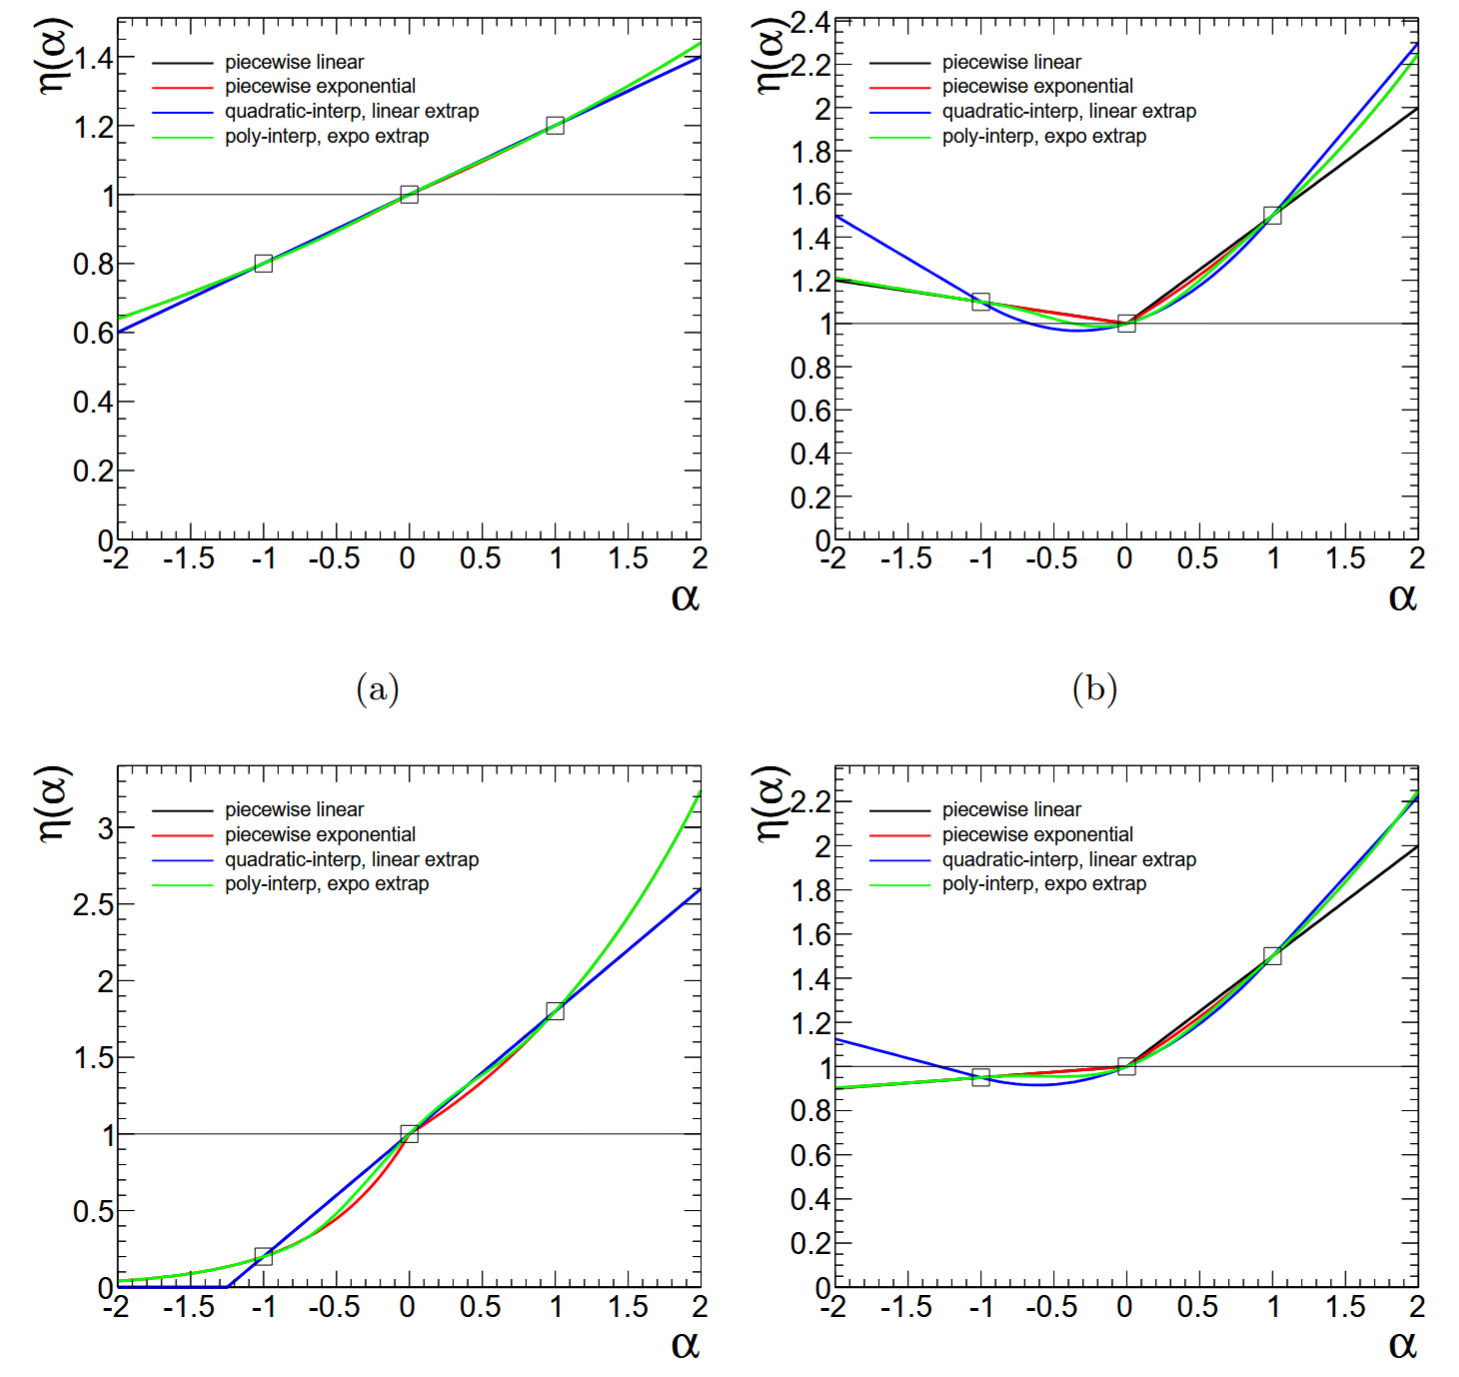

For normsys:
 - Polynomial Interpolation and Exponential Extrapolation (InterpCode=4)

For histosys:
 - Piecewise Linear (InterpCode=0)

In [ ]:
# now let's re-fit with the full model with all kinds of systematics
model, data = cabinetry.model_utils.model_and_data(spec)

In [ ]:
fit_results = cabinetry.fit.fit(model, data)

In [ ]:
model_pred_postfit = cabinetry.model_utils.prediction(model, fit_results=fit_results)
fig = cabinetry.visualize.data_mc(model_pred_postfit, data, config=config, colors =  {"signal":"red", "background":"lightgrey"})
fig[0]['figure'].get_axes()[0].set_ylim(0,10)
fig[0]['figure'].get_axes()[0].set_xlim(-0.1,2)
fig[0]['figure'].get_axes()[1].set_xlim(-0.1,2)
fig[0]['figure'].get_axes()[1].set_ylim(-0.25,2.25)
fig[0]['figure'].get_axes()[1].set_yticks([0,0.5,1,1.5,2], labels = [0,0.5,1,1.5,2])
fig[0]['figure'].get_axes()[1].minorticks_off()

In [ ]:
for label, result, unc in zip(fit_results.labels, fit_results.bestfit, fit_results.uncertainty):
    print(f"{label}: {result:.3f} +/- {unc:.3f}")

In [ ]:
mu_uncertainty = fit_results.uncertainty[model.config.poi_index]

In [ ]:
# pull plot
exclude = r"$\mu$"
labels_np = np.asarray(fit_results.labels)

if exclude is None:
    exclude_set = set()
elif isinstance(exclude, str):
    exclude_set = {exclude}
else:
    exclude_set = set(exclude)
exclude_set.update(
    [
        label
        for i_np, label in enumerate(labels_np)
        if fit_results.uncertainty[i_np] == 0.0
    ]
)

mask = [True if label not in exclude_set else False for label in labels_np]
bestfit = fit_results.bestfit[mask]
uncertainty = fit_results.uncertainty[mask]
labels_np = labels_np[mask]

num_pars = len(bestfit)
y_positions = np.arange(num_pars)[::-1]
fig, ax = plt.subplots(figsize=(6, 1 + num_pars / 4), dpi=100, layout="constrained")
ax.errorbar(bestfit, y_positions, xerr=uncertainty, fmt="o", color="black")

ax.fill_between([-2, 2], -0.5, len(bestfit) - 0.5, color="green", ec ="black",)
ax.fill_between([-1, 1], -0.5, len(bestfit) - 0.5, color="yellow",ec ="black",)
ax.vlines(0, -0.5, len(bestfit) - 0.5, linestyles="dotted", color="black")

ax.set_xlim([-3, 3])
ax.set_xlabel(r"$\left(\hat{\theta} - \theta_0\right) / \Delta \theta$")
ax.set_ylim([-0.5, num_pars - 0.5])
ax.set_yticks(y_positions)
ax.set_yticklabels(labels_np)
ax.xaxis.set_minor_locator(mpl.ticker.AutoMinorLocator())  # minor ticks
ax.tick_params(axis="both", which="major", pad=8)
ax.tick_params(direction="in", top=True, right=True, which="both")

In [ ]:
# another pull plot
exclude = r"$\mu$"
labels_np = np.asarray(fit_results.labels)

if exclude is None:
    exclude_set = set()
elif isinstance(exclude, str):
    exclude_set = {exclude}
else:
    exclude_set = set(exclude)

exclude_set.update(
    [
        label
        for i_np, label in enumerate(labels_np)
        if fit_results.uncertainty[i_np] == 0.0
    ]
)

mask = [True if label not in exclude_set else False for label in labels_np]
bestfit = fit_results.bestfit[mask]
uncertainty = fit_results.uncertainty[mask]
labels_np = labels_np[mask]

num_pars = len(bestfit)
y_positions = np.arange(num_pars)[::-1]
fig, ax = plt.subplots(figsize=(6+1, 1 + num_pars / 4), dpi=100, layout="constrained")
ax.errorbar(bestfit[:2], y_positions[:2], xerr=uncertainty[:2], fmt="o", color="black")

errsize=np.sqrt(4) ###########################################################################################
ax.errorbar(bestfit[2:]-1, y_positions[2:], xerr=uncertainty[2:]*errsize, fmt="o", color="black")

ax.fill_between([-2, 2], -0.5, len(bestfit) - 0.5, color="green", ec ="black",)
ax.fill_between([-1, 1], -0.5, len(bestfit) - 0.5, color="yellow",ec ="black",)
ax.vlines(0, -0.5, len(bestfit) - 0.5, linestyles="dotted", color="black")


ax.set_xlim([-3, 3])
ax.set_xlabel(r"$\left(\hat{\theta} - \theta_{0/1}\right) / \Delta \theta$")
ax.set_ylim([-0.5, num_pars - 0.5])
ax.set_yticks(y_positions)
ax.set_yticklabels(labels_np)
ax.xaxis.set_minor_locator(mpl.ticker.AutoMinorLocator())  # minor ticks
ax.tick_params(axis="both", which="major", pad=8)
ax.tick_params(direction="in", top=True, right=True, which="both")


s = (r"$\theta_{1}$ is used for shapesys and staterror")

plt.text(0.5, -0.6, s,
         transform=ax.transAxes, fontsize=10)

In [ ]:
cabinetry.visualize.correlation_matrix(fit_results, pruning_threshold=0.0)

Note that in this model all systematics are uncorrelated!

In [ ]:
print("", mu_uncertainty, "\n",
      
     np.sqrt(2**2+ # data stat. unc
             4+    # staterror 
             4+    # histosys
             4+    # normsys
             4     # shapesys 
            )
)

Kind of still makes sense, but we know exactly the uncertainty we plug in

And after the fit we get a single number as uncertainty on POI.

In real world, it is important to disentangle the uncertainty into statistical and systematic.

$\sigma_{\mu} = \ ??(stat.) \ \pm \ ??(syst.) = 4.5$

For such simple model, we knew the statistical uncertainty from the very beginning. 

But how to get it from the fit?

Under the pure frequentist approach, the statistical uncertainty is a standard deviation of the estimator when the exact same experiment is repeated (also with the same systematic uncertainties) on independent data samples of identical expected size.
(<span style="color: red;">disclaimer: this is my interpretation for this excercise.</span>)

Let's do that exactly. But we do not have more independent samples. 

As data counts follow Poisson distribution, we can evaluate the statistical uncertainty using an ensemble of pseudo-experiments (toys) by sampling data with Poisson distribution.

In [ ]:
asimov_data = cabinetry.model_utils.asimov_data(
    model=model, 
    poi_name=r"$\mu$", 
    poi_value=0,
    include_auxdata=False,
)
ntoys = 1000
data_toys = [np.random.poisson(asimov_data) for i in range(ntoys)]

In [ ]:
params_toys = []
for i in range(ntoys):
    fit_results = pyhf.infer.mle.fit(
                list(data_toys[i]) + model.config.auxdata, 
                model,
                return_uncertainties=False,
            )
    params_toys.append(fit_results)

In [ ]:
def plot_mutoy(params_toys):

    mu_index = model.config.poi_index
    mu_index = mu_index

    fig, ax = plt.subplots(figsize=(10, 8))

    points = np.array([j[mu_index] for j in params_toys])

    pars_value = points[:]
    pars_value = pars_value[pars_value > -99]

    par_name = r"$\mu$"
    par_label = par_name
    pars_norm = (pars_value)

    plt.hist(
        pars_norm, #range=(-3,3),
        bins=100,
        color="black",
        histtype="step",
        linewidth=2,
    )

    plt.xlabel(f"Fitted {par_label}", size=20)
    plt.ylabel("Entries / bin", size=20)

    mean = np.mean(pars_norm)
    median = np.median(pars_norm)
    sigma_minus = median - np.percentile(pars_norm, (100-68.2)/2)
    sigma_plus = np.percentile(pars_norm, (100+68.2)/2) - median
    sigma = (sigma_minus + sigma_plus)/2.

    sigma_mu = sigma
    print(f"µ = {median:.2f} ± {sigma:.2f}  \n         + {sigma_plus:.2f}\n         - {sigma_minus:.2f}")

    textstr = '\n'.join([
        fr"median={median:.3f}",
        fr"$\sigma_-$={sigma_minus:.3f}",
        fr"$\sigma_+$={sigma_plus:.3f}",
    ])
    props = dict(boxstyle='square', facecolor='white', alpha=0.3)

    plt.text(
        0.75, 
        0.9, 
        textstr, 
        transform=ax.transAxes, 
        fontsize=15,
        verticalalignment='top', 
        bbox=props
    )
    plt.show()
    plt.close()

    return sigma_mu

In [ ]:
sigma_mu_stat = plot_mutoy(
    params_toys=params_toys,
)

Note that this distribution is very non-Gaussian.

As the model itself is Poisson, it makes sense to take median for the central value of the estimator (is it biased?) and the $\pm$ 68% quantiles of the distribution as statistical uncertainty.

This coincides with our expectation on what the statistical uncertainty of such model is.

Remember when we have saved the uncertainty on POI?

By subtracting the statistical uncertainty from it we get the total systematic contribution (quite standard approach).

In [ ]:
totsyst = np.sqrt(mu_uncertainty**2 - sigma_mu_stat**2)
print(totsyst)

However, it does not tell us which systematics are more/less important.

We can make some very naive estimates, for which we already have all ingredients.

We take POI uncertainty from fit with a single NP and subtract the POI uncertainty 
from the fit with no systematics in quadrature.

Code-wise can be wrapped as:

In [ ]:
model4, data4 = cabinetry.model_utils.model_and_data(minispec[4])
fixed_systs_mu =cabinetry.fit.fit(model4, data4).uncertainty[0]

In [ ]:
model, data = cabinetry.model_utils.model_and_data(spec)

par_names = model.config.par_names

dict_syst = {}

for aux_index in range(0,len(par_names)):
        
        if aux_index == model.config.poi_index:
            continue
        
        fixed_params = model.config.suggested_fixed()
        for aux_index2 in range(0,len(par_names)):
                if(aux_index2 != model.config.poi_index):
                    fixed_params[aux_index2] = True
        
        fixed_params[aux_index] = False

        fit_results = cabinetry.fit.fit(model, data, fix_pars=fixed_params)
        fitted_mu=[fit_results.bestfit[model.config.poi_index], fit_results.uncertainty[model.config.poi_index]]

        print(f"--- {par_names[aux_index]}, mu unc = {fitted_mu[1]}")
        dict_syst[par_names[aux_index]] = fitted_mu[1]        
        


In [ ]:
syst_nomi = {}
for k in dict_syst:
    subtracted = np.sqrt(dict_syst[k]**2 - fixed_systs_mu**2)
    syst_nomi[k] = subtracted

a = {k: v for k, v in sorted(syst_nomi.items(), key=lambda item: -item[1])}

tot = 0
for k in a:
    print(k,a[k])
    tot += a[k]**2

print("Total syst",np.sqrt(tot))

###### BUT DO NOT DO IT LIKE THIS.

It will ~never give correct result and completely neglects correlations between NPs.

For something smarter, we can use some cabinetry helpers.

In [ ]:
model, data = cabinetry.model_utils.model_and_data(spec)
fit_results = cabinetry.fit.fit(model, data)
ranking_results = cabinetry.fit.ranking(model, data, fit_results=fit_results, # in real world you do not need extra args.
                                        impacts_method = 'np_shift')          # this argument does not exist yet in main brach
                                                                               # but is default in main (cabinetry main)

In [ ]:
cabinetry.visualize.ranking(ranking_results, max_pars = 10)

In [ ]:
tot = 0
for i in range(len(ranking_results.labels)):
    print(ranking_results.labels[i], (abs(ranking_results.prefit_down[i])+abs(ranking_results.prefit_up[i]))/2 )
    tot += ((abs(ranking_results.prefit_down[i])+abs(ranking_results.prefit_up[i]))/2)**2
        
print("Total syst",np.sqrt(tot))

Well, this seems to give us what we want. 

However, what does it do?

1) The data is fixed

2) Every nuisance parameter is shifted up/down by 1 $\sigma$ and fixed.

3) Fit is repeated

4) The difference between the nominal fit POI central value and POI central value from fit with shifted systematic is taken as $\Delta$POI

[cabinetry docs](https://cabinetry.readthedocs.io/en/latest/api.html#cabinetry.fit.ranking)


This is a widely used approach, routinely these numbers are called 'impacts' on POI.

There is slight problem here; this is a profiled-likelihood fit. Shifting the NP changes the shape of the likelihood. 

Okay, we get 2's, 4's etc in places where we expect for such simple model.

But is any of these numbers an uncertainty? Or do they just look suspiciously close?

Okay, this is exactly what we will try to find out.
- The opposite of a "common" approach can be explored:
- we will try to directly get the systematic uncertainties in the fit and subtract it in quadrature from the total fit uncertainty.
- The question then is: do we get the statistical uncertainty then (which we can estimate using toys)?

In [ ]:
counting_spec = deepcopy(spec)

## A more 'realistic' example can be employed

In [ ]:
distrobg = list([0.5]*np.ones(10)) +\
    list([1.5]*np.ones(10)) +\
    list([2.5]*np.ones(10)) +\
    list([3.5]*np.ones(10)) +\
    list([4.5]*np.ones(10)) +\
    list([5.5]*np.ones(10)) +\
    list([6.5]*np.ones(10)) +\
    list([7.5]*np.ones(10)) +\
    list([8.5]*np.ones(10))

distrosi = list([3.5]*np.ones(2)) +\
    list([4.5]*np.ones(3)) +\
    list([5.5]*np.ones(2))

In [ ]:
wdiamond = list([1]*np.ones(10)) +\
    list([1.2]*np.ones(10)) +\
    list([1.4]*np.ones(10)) +\
    list([1.6]*np.ones(10)) +\
    list([1.8]*np.ones(10)) +\
    list([1.6]*np.ones(10)) +\
    list([1.4]*np.ones(10)) +\
    list([1.2]*np.ones(10)) +\
    list([1]*np.ones(10))

wrsleeve = list([1]*np.ones(10)) +\
    list([1.1]*np.ones(10)) +\
    list([1.2]*np.ones(10)) +\
    list([1.3]*np.ones(10)) +\
    list([1.4]*np.ones(10)) +\
    list([1.5]*np.ones(10)) +\
    list([1.6]*np.ones(10)) +\
    list([1.7]*np.ones(10)) +\
    list([1.8]*np.ones(10))

wlsleeve = list([1.8]*np.ones(10)) +\
    list([1.7]*np.ones(10)) +\
    list([1.6]*np.ones(10)) +\
    list([1.5]*np.ones(10)) +\
    list([1.4]*np.ones(10)) +\
    list([1.3]*np.ones(10)) +\
    list([1.2]*np.ones(10)) +\
    list([1.1]*np.ones(10)) +\
    list([1.0]*np.ones(10))

wsqueeze = list([1.8]*np.ones(10)) +\
    list([1.6]*np.ones(10)) +\
    list([1.4]*np.ones(10)) +\
    list([1.2]*np.ones(10)) +\
    list([1.0]*np.ones(10)) +\
    list([1.2]*np.ones(10)) +\
    list([1.4]*np.ones(10)) +\
    list([1.6]*np.ones(10)) +\
    list([1.8]*np.ones(10))

In [ ]:
S1 = {"variable": distrosi, "weights" : [1]*np.ones(7)}
B1 = {"variable": distrobg, "weights" : [1]*np.ones(90), 
                            "wsqueeze" : wsqueeze,
                            "wdiamond" : wdiamond,
                            "wrsleeve" : wrsleeve,
                            "wlsleeve" : wlsleeve
     }
D1 = {"variable": distrobg, "weights" : [1]*np.ones(90)}

In [ ]:
write_root_with_uproot("./data2.root", "pseudodata", D1)
write_root_with_uproot("./signal2.root", "signal", S1)
write_root_with_uproot("./background2.root", "background", B1)

In [ ]:
config = {
   "General":{
      "Measurement": "Still None",
      "POI": r"$\mu$",              
      "InputPath": "./{SamplePath}",
      "HistogramFolder": "histograms/"
   }
}

In [ ]:
binning = list(np.linspace(0, 9, 10))
config.update({
    "Regions":[
        {
            "Name": r"peak fitting",
            "Filter": f"variable==variable",
            "Variable": "variable",      
            "Binning": binning
        },
   ]
})

In [ ]:
config.update({
   "Samples":[
      {
         "Name": "pseudodata",
         "Tree": "pseudodata",
         "SamplePath": "data2.root", 
         "Data": True,
         "Weight": "weights"
      },
      {
         "Name": "signal",
         "Tree": "signal",
         "SamplePath": "signal2.root", 
         "Weight": "weights",
         "DisableStaterror": True # we do not want them for simplicity
      },
      {
         "Name": "background",
         "Tree": "background",
         "SamplePath": "background2.root",
         "Weight": "weights",
         "DisableStaterror": True # we do not want them for simplicity
      },
   ]
})

In [ ]:
config.update({"Systematics": []})

config.update({
   "NormFactors":[
      {
         "Name": r"$\mu$",
         "Samples": "signal",
         "Nominal": 0.0,
         "Bounds": [-20, +20]
      }
   ]
})

In [ ]:
config.update({
    "Systematics":[
        {
            "Name": "Diamond",
            "Up": {"Weight": "weights*wdiamond"},
            "Down": {"Weight": "weights*(2-wdiamond)"},
            "Samples": [
                "background",
            ],
            "Regions": [
                "peak fitting",
            ],
             "Type": "NormPlusShape"
        },
        {
            "Name": "Squeeze",
            "Up": {"Weight": "weights*wsqueeze"},
            "Down": {"Weight": "weights*(2-wsqueeze)"},
            "Samples": [
                "background",
            ],
            "Regions": [
                "peak fitting",
            ],
             "Type": "NormPlusShape"
        },    
        {
            "Name": "Right Sleeve",
            "Up": {"Weight": "weights*wrsleeve"},
            "Down": {"Weight": "weights*(2-wrsleeve)"},
            "Samples": [
                "background",
            ],
            "Regions": [
                "peak fitting",
            ],
             "Type": "NormPlusShape"
        },
        {
            "Name": "Left Sleeve",
            "Up": {"Weight": "weights*wlsleeve"},
            "Down": {"Weight": "weights*(2-wlsleeve)"},
            "Samples": [
                "background",
            ],
            "Regions": [
                "peak fitting",
            ],
             "Type": "NormPlusShape"
        },  
        {
            "Name": "Normalization 20%",
            "Up": {"Normalization": +0.2}, # if you are making pyhf model yourself, the normalizations are 1.2, 0.8 
            "Down": {"Normalization": -0.2},
            "Samples": [
                "background",
            ],
            "Regions": [
                "peak fitting",
            ],
            "Type": "Normalization"
        },
        #
        
        #
    ],
})


The shapes of modifiers can be represented as following:
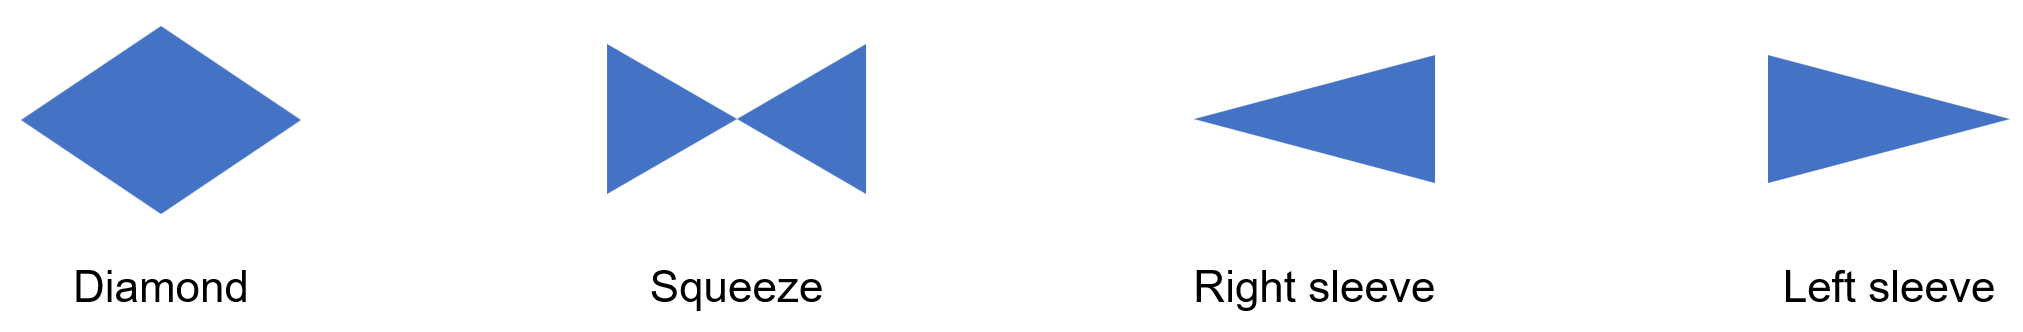

In [ ]:
cabinetry.configuration.validate(config)

In [ ]:
cabinetry.configuration.print_overview(config)

cabinetry.templates.build(config, method="uproot")

cabinetry.templates.postprocess(config)

In [ ]:
fig = cabinetry.visualize.data_mc_from_histograms(config, colors =  {"signal":"red", "background":"lightgrey"}) # "lightgrey"
fig[0]['figure'].get_axes()[0].set_ylim(0,25)
fig[0]['figure'].get_axes()[0].set_xlim(-0.5,12)
fig[0]['figure'].get_axes()[1].set_xlim(-0.1,12)
fig[0]['figure'].get_axes()[1].set_ylim(0.5,1.5)
fig[0]['figure'].get_axes()[1].set_yticks([0,0.5,1,1.5,2], labels = [0,0.5,1,1.5,2])

fig[0]['figure'].get_axes()[1].minorticks_off()

In [ ]:
_ = cabinetry.visualize.templates(config)

In [ ]:
workspace_path = "json/peak_fitting_workspace.json"
spec = cabinetry.workspace.build(config)

In [ ]:
spec

In [ ]:
cabinetry.workspace.save(spec, workspace_path)

In [ ]:
c = cabinetry.visualize.modifier_grid(pyhf.Workspace(spec).model(),close_figure=False)
locs, labels = plt.xticks()
ll =[]
for i in range(len(labels)):
        ll.append(fr'{labels[i].get_text()}')
plt.xticks(locs, ll, rotation='vertical', horizontalalignment='center')
c.set_figwidth(c.get_figwidth()*2.1)
c.set_figheight(c.get_figheight()*2.1) 

In [ ]:
model, data = cabinetry.model_utils.model_and_data(spec)

In [ ]:
fit_results = cabinetry.fit.fit(model, data)

In [ ]:
for label, result, unc in zip(fit_results.labels, fit_results.bestfit, fit_results.uncertainty):
    print(f"{label}: {result:.3f} +/- {unc:.3f}")

In [ ]:
cabinetry.visualize.pulls(fit_results, exclude=r"$\mu$")

In [ ]:
cabinetry.visualize.correlation_matrix(fit_results, pruning_threshold=0.0)

In [ ]:
model_pred_postfit = cabinetry.model_utils.prediction(model, fit_results=fit_results)
fig = cabinetry.visualize.data_mc(model_pred_postfit, data, config=config, colors =  {"signal":"red", "background":"lightgrey"})
fig[0]['figure'].get_axes()[0].set_ylim(0,25) 
fig[0]['figure'].get_axes()[0].set_xlim(-0.5,12)
fig[0]['figure'].get_axes()[1].set_xlim(-0.1,12)
fig[0]['figure'].get_axes()[1].set_ylim(0.5,1.5)
fig[0]['figure'].get_axes()[1].set_yticks([0,0.5,1,1.5,2], labels = [0,0.5,1,1.5,2])

fig[0]['figure'].get_axes()[1].minorticks_off()

In [ ]:
mu_uncertainty = fit_results.uncertainty[model.config.poi_index]

In [ ]:
asimov_data = cabinetry.model_utils.asimov_data(
    model=model, 
    poi_name=r"$\mu$", 
    poi_value=0,
    include_auxdata=False,
)


ntoys = 1000
n_batches = 100
data_toys = [np.random.poisson(asimov_data, size=(ntoys, len(asimov_data))) for i in range(n_batches)]

In [ ]:
def fit_batch(
    data_toys,
):
    params_toys = []
    for data_toy in data_toys:
        try:
            fit_results = pyhf.infer.mle.fit(
                list(data_toy) + model.config.auxdata, 
                model,
                return_uncertainties=False,
            )
            params_toys.append(fit_results)
        except Exception:
            params_toys.append(np.ones(len(model.config.auxdata)+1)*(-999))

    return params_toys

In [ ]:
U = partial(fit_batch)

t0 = time.time()
pool = Pool(n_batches)
res = pool.map(U, data_toys)
pool.close()

params_toys = sum(res, [])
toytime = f"{time.time()-t0:.1f} seconds"
print(f"{len(params_toys)} toys took {toytime}")

In [ ]:
sigma_mu_stat = plot_mutoy(
    params_toys=params_toys,
)

In [ ]:
da = list(data_toys[-20][-20])
fit_results = cabinetry.fit.fit(model, da+model.config.auxdata)

model_pred_postfit = cabinetry.model_utils.prediction(model, fit_results=fit_results)
fig = cabinetry.visualize.data_mc(model_pred_postfit, da, config=config, colors =  {"signal":"red", "background":"lightgrey"})
fig[0]['figure'].get_axes()[0].set_ylim(0,25) 
fig[0]['figure'].get_axes()[0].set_xlim(-0.5,12)
fig[0]['figure'].get_axes()[1].set_xlim(-0.1,12)
fig[0]['figure'].get_axes()[1].set_ylim(0.5,1.5)
fig[0]['figure'].get_axes()[1].set_yticks([0,0.5,1,1.5,2], labels = [0,0.5,1,1.5,2])

fig[0]['figure'].get_axes()[1].minorticks_off()

We can compare the statistical uncertainty obtained from toys to the uncertainty of the fit with no systematics

In [ ]:
peak_nosyst_spec = deepcopy(spec)
remove_modtypes(peak_nosyst_spec, { "normsys", "histosys"})

c = cabinetry.visualize.modifier_grid(pyhf.Workspace(peak_nosyst_spec).model(),close_figure=False)
locs, labels = plt.xticks()
ll =[]
for i in range(len(labels)):
        ll.append(fr'{labels[i].get_text()}')
plt.xticks(locs, ll, rotation='vertical', horizontalalignment='center')
c.set_figwidth(c.get_figwidth()*2.1)
c.set_figheight(c.get_figheight()*2.1) 

model, data = cabinetry.model_utils.model_and_data(peak_nosyst_spec)
fit_results = cabinetry.fit.fit(model, data)


print(f"\n\nUncertainty on POI from fit with no systematics: {fit_results.uncertainty[model.config.poi_index]}")
print(f"Statistical uncertainty on POI from toys: {sigma_mu_stat}")

It does not match by a lot, so these two things are not the same thing.

Now we can safely use the helpers from cabinetry to get the impacts on POI

In [ ]:
model, data = cabinetry.model_utils.model_and_data(spec)
fit_results = cabinetry.fit.fit(model, data)

In [ ]:
ranking_results = cabinetry.fit.ranking(model, data, fit_results=fit_results, # in perfect world you do not need extra args.
                                        impacts_method = 'np_shift')

In [ ]:
cabinetry.visualize.ranking(ranking_results, max_pars = 20)

In [ ]:
print("uncertainty on fitted mu pre fit")
tot = 0
for i in range(len(ranking_results.labels)):
    print(ranking_results.labels[i], (abs(ranking_results.prefit_down[i])+abs(ranking_results.prefit_up[i]))/2 )
    tot += ((abs(ranking_results.prefit_down[i])+abs(ranking_results.prefit_up[i]))/2)**2

print("Total syst",np.sqrt(tot))

In [ ]:
np.sqrt(mu_uncertainty**2 - tot)

In [ ]:
print("uncertainty on fitted mu post fit")
tot = 0
for i in range(len(ranking_results.labels)):
    print(ranking_results.labels[i], (abs(ranking_results.postfit_down[i])+abs(ranking_results.postfit_up[i]))/2 )
    tot += ((abs(ranking_results.postfit_down[i])+abs(ranking_results.postfit_up[i]))/2)**2
print("Total syst",np.sqrt(tot))

In [ ]:
np.sqrt(mu_uncertainty**2 - tot)

In [ ]:
print("uncertainty on fitted mu post fit")
tot = 0
for i in range(len(ranking_results.labels)):
    print(ranking_results.labels[i], (abs(ranking_results.postfit_up[i])) )
    tot += (abs(ranking_results.postfit_up[i]))**2
print("Total syst",np.sqrt(tot))
print("UP")

In [ ]:
np.sqrt(mu_uncertainty**2 - tot)

In [ ]:
print("uncertainty on fitted mu post fit")
tot = 0
for i in range(len(ranking_results.labels)):
    print(ranking_results.labels[i], (abs(ranking_results.postfit_down[i])) )
    tot += (abs(ranking_results.postfit_down[i]))**2
print("Total syst",np.sqrt(tot))
print("DOWN")

In [ ]:
np.sqrt(mu_uncertainty**2 - tot)

In [ ]:
print("uncertainty on fitted mu pre fit")
tot = 0
for i in range(len(ranking_results.labels)):
    print(ranking_results.labels[i], (abs(ranking_results.prefit_up[i])) )
    tot += (abs(ranking_results.prefit_up[i]))**2
print("Total syst",np.sqrt(tot))
print("UP")

In [ ]:
np.sqrt(mu_uncertainty**2 - tot)

In [ ]:
print("uncertainty on fitted mu pre fit")
tot = 0
for i in range(len(ranking_results.labels)):
    print(ranking_results.labels[i], (abs(ranking_results.prefit_down[i])) )
    tot += (abs(ranking_results.prefit_down[i]))**2
print("Total syst",np.sqrt(tot))
print("DOWN")

In [ ]:
np.sqrt(mu_uncertainty**2 - tot)

In [ ]:
print(sigma_mu_stat)

Attempt of getting statistical uncertainty by subtraction in quadrature does give nans in many cases, which means the method does not return statistical uncertainties.

#### Lets check the other approach which neglects all correlations

In [ ]:
par_names = model.config.par_names
dict_syst = {}

for aux_index in range(0,len(par_names)):
        
        fixed_params = model.config.suggested_fixed()
        for aux_index2 in range(0,len(par_names)):
                if(aux_index2 != model.config.poi_index):
                    fixed_params[aux_index2] = True
        
        print(f"{aux_index}/{len(par_names)}")
        fixed_params[aux_index] = False

        fit_results = cabinetry.fit.fit(model, data, fix_pars=fixed_params)
        fitted_mu=[fit_results.bestfit[model.config.poi_index], fit_results.uncertainty[model.config.poi_index]]

        print(f"{par_names[aux_index]} --> μ = {fitted_mu[0]} ± {fitted_mu[1]}")
        dict_syst[par_names[aux_index]] = fitted_mu[1]        
        


In [ ]:
syst_nomi = {}
for k in dict_syst:
    asd = np.sqrt(dict_syst[k]**2- dict_syst['$\\mu$']**2)

    syst_nomi[k] = asd

a = {k: v for k, v in sorted(syst_nomi.items(), key=lambda item: -item[1])}

alltot = 0
for k in a:
    if '\mu' not in k:
        print(k,a[k])
    alltot += a[k]**2
print("Total:" ,np.sqrt(alltot))

In [ ]:
np.sqrt(mu_uncertainty**2 - alltot)

In [ ]:
print(sigma_mu_stat)

#### We knew it is very bad. And this estimation ultimately fails under the presence of correlations.

## Conclusion

The default cabinetry helper method does not give us statistical uncertainty when total systematic is subtracted in quadrature from the best-fit uncertainty.
- It means that the components of what is going into the total systematic are also not uncertainties on POI coming from a selected systematic source.
- Kind of expeceted because the procedure changes the shape of the likelihood.
- It is called "ranking" and operates in "impacts", not uncertainties -- Maybe never meant to give uncertainties.

The approach that neglects correlations between nuisance parameters also yields insufficient systematic uncertainty estimations.
- These are not uncertainties either. 
- Correlations are important
- Even ranking here is wrong

To do better we should use more real-life approaches.

# Approach used in $B \to K \nu \nu$

[arXiv:2311.14647](https://arxiv.org/abs/2311.14647)

 1. A single NP is <span style="color: red;">fixed</span> for a single fit (to its best-fit value).
 2. Fit is repeated with a modified model.
 3. The difference in quadrature between the nominal fit error on POI error on POI with one systematic fixed and the is taken as an impact on POI

In [ ]:
par_names = model.config.par_names
dict_syst = {}
for aux_index in range(0,len(par_names)):

        print(f"{aux_index}/{len(par_names)}")
        
        fixed_params = model.config.suggested_fixed()
        if(aux_index != model.config.poi_index):
            fixed_params[aux_index] = True

        fit_results = cabinetry.fit.fit(model, data, fix_pars=fixed_params)
        fitted_mu=[fit_results.bestfit[model.config.poi_index], fit_results.uncertainty[model.config.poi_index]]

        print(f"      {par_names[aux_index]}: mu = {fitted_mu[0]} ± {fitted_mu[1]}")
        dict_syst[par_names[aux_index]] = fitted_mu[1]        

In [ ]:
syst_nomi = {}
for k in dict_syst:
    asd = np.sqrt(dict_syst['$\\mu$']**2 - dict_syst[k]**2)

    syst_nomi[k] = asd

a = {k: v for k, v in sorted(syst_nomi.items(), key=lambda item: -item[1])}

alltot = 0
for k in a:
    if '\mu' not in k:
        print(k,a[k])
    alltot += a[k]**2
    
print("Total" ,np.sqrt(alltot))

In [ ]:
np.sqrt(mu_uncertainty**2 - alltot)

In [ ]:
print(sigma_mu_stat)

Slight undershoot of statistical uncertainty.

# Approach used in $\tau$ LFU

[arXiv:2405.14625](https://arxiv.org/abs/2405.14625)

 1. Sample auxdata for a single systematic source.
 2. Repeat the fit for every sampled auxdata.
 3. Take std of POI distribution from fits as uncertainty on POI from that systematic source


In [ ]:
# Thanks to Paul for providing his code :)
def get_aux_slice_dict(model):
    """
    get slice dictionary for auxiliary data (indexed according to maindata + auxdata)
    """
    slice_edges = np.insert(np.cumsum([model.config.param_set(aux_name).n_parameters for aux_name in model.config.auxdata_order]), 0, 0)
    slice_edges += model.config.nmaindata
    slice_dict = {aux_name: slice(slice_edges[i], slice_edges[i + 1]) for i, aux_name in enumerate(model.config.auxdata_order)}
    return slice_dict


def make_sys_toys(model, sys_name, n_toys=100, assumed_value=None, n1=False, init_pars=None):
    """
    return toy sample with sampled auxdata for selected systematic source
    n1 samples all data except for sys_name
    sys_name can be partial name of auxdata
    if sys_name is None, the expected data is returned (n1=False), or the full toy data (n1=True)
    if sys_name is 'data_stat_error', maindata is sampled
    """

    if init_pars is None:
        pars = model.config.suggested_init()
    else:
        pars = init_pars
    if assumed_value is not None:
        pars[model.config.poi_index] = assumed_value

    # create toys
    toys = model.make_pdf(pyhf.tensorlib.astensor(pars)).sample((n_toys, ))  # toy data

    # create expected toy data
    expected_toys = np.tile(model.expected_data(pars), (n_toys, 1))

    if sys_name == 'data_stat_error':
        if n1:  # inverted
            expected_toys[:, model.config.nmaindata:] = toys[:, model.config.nmaindata:]
        else:
            expected_toys[:, :model.config.nmaindata] = toys[:, :model.config.nmaindata]
    else:
        slice_dict = get_aux_slice_dict(model)

        if n1:  # inverted
            expected_toys[:, :model.config.nmaindata] = toys[:, :model.config.nmaindata]  # use toy data
            slices = [aux_sl for aux_name, aux_sl in slice_dict.items() if (sys_name is None) or (sys_name not in aux_name)]
        else:
            slices = [aux_sl for aux_name, aux_sl in slice_dict.items() if (sys_name is not None) and (sys_name in aux_name)]

        # replace cunck of expected toys corresponding to variation of auxiliary data correspong to sys
        for sl in slices:
            expected_toys[:, sl] = toys[:, sl]

    return expected_toys


def uncertainty_toys(model, sys_names=['data_stat_error'], n_toys=500, fix_pars_in_fit=False, fix_data_stat=True, init_pars=None, assumed_poi_value=None):

    pyhf.set_backend("numpy", pyhf.optimize.scipy_optimizer())  # very fast

    if init_pars is None:
        init_pars = model.config.suggested_init()

    if assumed_poi_value is None:
        assumed_value = init_pars[model.config.poi_index]
    else:
        assumed_value = assumed_poi_value

    result_dict = {}

    for sys_name in sys_names:
        print(sys_name)
        sys_toys = make_sys_toys(model, sys_name, n_toys=n_toys, assumed_value=assumed_value, n1=False, init_pars=init_pars)

        if fix_pars_in_fit or (fix_data_stat and (sys_name == 'data_stat_error')):
            print(f'fixing parameters in fit for {sys_name}')
            slices = [model.config.par_slice(par_name) for par_i, par_name in enumerate(model.config.par_order) if sys_name in par_name]
            # fix all parameters, except the ones associated to sys (does not give correct results)
            fixed_params = [True] * model.config.npars
            fixed_params[model.config.poi_index] = False  # don't fix the poi

            for sl in slices:
                # print('set floating:', model.config.par_names[sl])
                fixed_params[sl] = [False] * (sl.stop - sl.start)
            # make sure we don't float a parameter that should be fixed
            assert np.asarray([fix1 for fix1, fix2 in zip(fixed_params, model.config.suggested_fixed()) if fix2]).all()
        else:
            fixed_params = model.config.suggested_fixed()

        toy_results = []
        bestfits = []
        n_fail = 0
        for toy in tqdm(sys_toys):
            try:
                par_estimates, toy_result = pyhf.infer.mle.fit(toy, model, return_result_obj=True,
                                                               return_uncertainties=False, fixed_params=fixed_params, init_pars=init_pars)
                toy_results.append(toy_result)
                assert toy_result.success

                bestfits.append(par_estimates[model.config.poi_index].item())
            except Exception as e:
                n_fail += 1
                print(e)
                print(f'optimisation failed already {n_fail} times :(')

        bestfits = np.array(bestfits)
        for poi_bound in model.config.suggested_bounds()[model.config.poi_index]:
            on_bound = np.isclose(bestfits, poi_bound)
            if on_bound.sum() > 0:
                print(f'{on_bound.sum()} poi values are on bound {poi_bound}, removing them')
                bestfits = bestfits[~on_bound]

        result_dict[sys_name] = bestfits

    return result_dict

In [ ]:
model, data = cabinetry.model_utils.model_and_data(spec)

In [ ]:
pyhf.set_backend("numpy", pyhf.optimize.minuit_optimizer())
par_estimates, result = pyhf.infer.mle.fit(data, model, return_result_obj=True, return_uncertainties=True)
print(model.config.par_order)
print(par_estimates)

In [ ]:
sys_names = ['data_stat_error', 'Diamond', 'Squeeze', 'Left Sleeve', 'Right Sleeve', 'Normalization 20%']# + ["Signal mimic S", "Signal mimic L"]
toy_results = uncertainty_toys(model, sys_names=sys_names, n_toys=5_000, fix_data_stat=False)

In [ ]:
for sys_name in sys_names:
    plt.hist(toy_results[sys_name], bins=100)
    plt.title(sys_name)
    plt.xlabel(model.config.par_names[model.config.poi_index])
    plt.show()

In [ ]:
toy_stds = np.array([np.std(bestfits) for bestfits in toy_results.values()])
for par_name, par_unc in zip(sys_names, toy_stds):
    print(par_name, par_unc)
print('total', np.sqrt(np.sum(toy_stds**2)))

In [ ]:
mu_uncertainty

In [ ]:
# w/o data
toy_stds = np.array([np.std(bestfits) for bestfits in toy_results.values()])
for par_name, par_unc in zip(sys_names[1:], toy_stds[1:]):
    print(par_name, par_unc)
    
totsys = np.sqrt(np.sum(toy_stds[1:]**2))
print('total', totsys)

In [ ]:
np.sqrt(mu_uncertainty**2 - totsys**2)

In [ ]:
sigma_mu_stat

Matches quite well!

However:
- Numerical - suffers from toy precision
- Occasionally you get to look at some exceptionally cursed plots (because of low yields + model is not real)
- Computationally expensive - takes time and bad for climate

# Approach used in $B \to K^{*0} \tau \tau$ 
[arXiv:2504.10042](https://arxiv.org/abs/2504.10042)

 1. Every NP’s auxdata is shifted up/down by 1(𝜎) and not fixed and allowed to vary within same constraint.
 2. Fit is repeated.
 3. The difference between nominal fit POI and ‘shifted systematic’ fit POI is taken as ΔPOI.
 
 Following procedure described in [arXiv:2307.04007](https://arxiv.org/abs/2307.04007)

In [ ]:
model, data = cabinetry.model_utils.model_and_data(spec)

In [ ]:
poi_value = 0

asimov_data = cabinetry.model_utils.asimov_data(
    model=model, 
    poi_name=r"$\mu$", 
    poi_value=poi_value,
    include_auxdata=True,
)

In [ ]:
def make_fit(data):
    fit_results = cabinetry.fit.fit(model=model,data=data)
    return [fit_results.bestfit[model.config.poi_index], fit_results.uncertainty[model.config.poi_index]]

In [ ]:
poi_value = 0
asimov_data = cabinetry.model_utils.asimov_data(
            model=model, 
            poi_name=r"$\mu$", 
            poi_value=poi_value,
            include_auxdata=True,
        )

In [ ]:
par_names = model.config.par_names
par_names.remove(r"$\mu$")

dict_syst = {}
dict_syst_up = {}
dict_syst_dn = {}

eod_index = len(binning)-1

for aux_index in range(0, len(par_names)):
    asimov_data = cabinetry.model_utils.asimov_data(
        model=model, 
        poi_name=r"$\mu$", 
        poi_value=poi_value,
        include_auxdata=True,
    )
    asimov_data[eod_index+aux_index] += 1
    fitted_mu_up = make_fit(asimov_data)
    print(f"{aux_index}/{len(par_names)}")
    print(f"+ {par_names[aux_index]}: mu = {fitted_mu_up[0]} ± {fitted_mu_up[1]}")

    asimov_data = cabinetry.model_utils.asimov_data(
        model=model, 
        poi_name=r"$\mu$", 
        poi_value=poi_value,
        include_auxdata=True,
    )
    asimov_data[eod_index+aux_index] += -1.0
    fitted_mu_dn = make_fit(asimov_data)

    print(f"- {par_names[aux_index]}: mu = {fitted_mu_dn[0]} ± {fitted_mu_dn[1]}")

    dict_syst[par_names[aux_index]] = (np.abs(fitted_mu_up[0]) + np.abs(fitted_mu_dn[0]))/2        
    dict_syst_up[par_names[aux_index]] = fitted_mu_up[0]
    dict_syst_dn[par_names[aux_index]] = fitted_mu_dn[0]


In [ ]:
dict_syst

In [ ]:
dict_syst_up

In [ ]:
dict_syst_dn

In [ ]:
impact_mu_up = {}
impact_mu_dn = {}

for par_name in dict_syst_up.keys():
    if dict_syst_up[par_name] > dict_syst_dn[par_name]:
        impact_mu_up[par_name] = dict_syst_up[par_name]
        impact_mu_dn[par_name] = dict_syst_dn[par_name]
    else:
        impact_mu_up[par_name] = dict_syst_dn[par_name]
        impact_mu_dn[par_name] = dict_syst_up[par_name]

In [ ]:
mydic={}
for syst_name in impact_mu_up.keys():
    mydic[syst_name] =(abs(impact_mu_up[syst_name]) + abs(impact_mu_dn[syst_name]))/2
    print(syst_name, (abs(impact_mu_up[syst_name]) + abs(impact_mu_dn[syst_name]))/2 )

In [ ]:
a = {k: v for k, v in sorted(mydic.items(), key=lambda item: item[1])}

In [ ]:
All = 0
StatMC = 0
for ke in list(a.keys())[::-1]:
    All += a[ke]**2
    if 'staterror' not in ke:
        print (f"{ke} & {a[ke]:0.5f}")
    else:
        StatMC += a[ke]**2
        
print (f"MC stat & {np.sqrt(StatMC):0.5f}")
print (f"Total & {np.sqrt(All):0.8f}")

In [ ]:
np.sqrt(mu_uncertainty**2 - All)

In [ ]:
mydic={}
for syst_name in impact_mu_up.keys():
    mydic[syst_name] =(abs(impact_mu_up[syst_name]))


a = {k: v for k, v in sorted(mydic.items(), key=lambda item: item[1])}

Allup = 0
StatMCup = 0
for ke in list(a.keys())[::-1]:
    Allup += a[ke]**2
    print (f"{ke} & {a[ke]:0.5f}")

print("UP")     
print (f"Total & {np.sqrt(Allup):0.8f}")

In [ ]:
mydic={}
for syst_name in impact_mu_up.keys():
    mydic[syst_name] =(abs(impact_mu_dn[syst_name]))

a = {k: v for k, v in sorted(mydic.items(), key=lambda item: item[1])}

Alldn = 0
for ke in list(a.keys())[::-1]:
    Alldn += a[ke]**2
    print (f"{ke} & {a[ke]:0.5f}")

print("DN")  
print (f"Total & {np.sqrt(Alldn):0.8f}")

In [ ]:
np.sqrt(mu_uncertainty**2 - All)

In [ ]:
np.sqrt(mu_uncertainty**2 - Allup)

In [ ]:
np.sqrt(mu_uncertainty**2 - Alldn)

In [ ]:
print(sigma_mu_stat)

Matches quite well!

Does not land precisely on the statistical uncertainty obtained with toys, but the trend is correct.

Does not suffer from toy precision.

In [ ]:
sigma_mu_stat = plot_mutoy(
    params_toys=params_toys,
)

In [ ]:
asimov_data = cabinetry.model_utils.asimov_data(
    model=model, 
    poi_name=r"$\mu$", 
    poi_value=0,
    include_auxdata=False,
)
data_toys = [np.random.poisson(asimov_data, size=(ntoys, len(asimov_data))) for i in range(n_batches)]

U = partial(fit_batch)

t0 = time.time()
pool = Pool(n_batches)
res = pool.map(U, data_toys)
pool.close()

params_toys = sum(res, [])
toytime = f"{time.time()-t0:.1f} seconds"
print(f"{len(params_toys)} toys took {toytime}")

In [ ]:
sigma_mu_stat = plot_mutoy(
    params_toys=params_toys,
)

Very unlikely that you would get the exact same numbers from the 2 sets of toys.

The estimations with toys always come with toy precision.

All the numbers today are coming with an uncertainty on uncertainty, however most do match with a reasonable degree.

## So why the not merged cabinetry PR?

Beacuse it has more helpers!

Do they give separate systematic uncertainties?

In [ ]:
model, data = cabinetry.model_utils.model_and_data(spec)

In [ ]:
fit_results = cabinetry.fit.fit(model, data)

In [ ]:
ranking_results = cabinetry.fit.ranking(model, data, fit_results=fit_results, 
                                        impacts_method = 'covariance') # new thing

Computes the impact of nuisance parameters on a parameter of interest by using their correlation in the post-fit covariance matrix.

Freeze NP at its post-fit value and recompute the covariance; the reduction in σ(μ) tells its contribution.

In [ ]:
cabinetry.visualize.ranking(ranking_results, max_pars = 20)

In [ ]:
print("uncertainty on fitted mu post fit")
tot = 0
for i in range(len(ranking_results.labels)):
    print(ranking_results.labels[i], (abs(ranking_results.postfit_down[i])+abs(ranking_results.postfit_up[i]))/2 )
    tot += ((abs(ranking_results.postfit_down[i])+abs(ranking_results.postfit_up[i]))/2)**2
print("Total syst",np.sqrt(tot))

In [ ]:
np.sqrt(mu_uncertainty**2 - tot)

In [ ]:
print(sigma_mu_stat)

Yes, reasonable match!

--------------------------------------------------------

In [ ]:
ranking_results = cabinetry.fit.ranking(model, data, fit_results=fit_results, 
                                        impacts_method = 'auxdata_shift')

Computes the impact of a parameter on the POI by shifting its associated
    auxiliary data values by its uncertainty and re-evaluating the fit with
    all parameters floating.
    
Should be same as in $B\to K^{*0} \tau \tau$ analysis.


In [ ]:
cabinetry.visualize.ranking(ranking_results, max_pars = 20)

In [ ]:
print("uncertainty on fitted mu post fit")
tot = 0
for i in range(len(ranking_results.labels)):
    print(ranking_results.labels[i], (abs(ranking_results.postfit_down[i])+abs(ranking_results.postfit_up[i]))/2 )
    tot += ((abs(ranking_results.postfit_down[i])+abs(ranking_results.postfit_up[i]))/2)**2
print("Total syst",np.sqrt(tot))

In [ ]:
np.sqrt(mu_uncertainty**2 - tot)

In [ ]:
print(sigma_mu_stat)

In [ ]:
for i in range(len(ranking_results.labels)):
    dict_syst_up[ranking_results.labels[i]] = ranking_results.postfit_up[i]
    dict_syst_dn[ranking_results.labels[i]] = ranking_results.postfit_down[i]

In [ ]:
impact_up = {}
impact_dn = {}

for par_name in dict_syst_up.keys():
    if dict_syst_up[par_name] > dict_syst_dn[par_name]:
        impact_up[par_name] = dict_syst_up[par_name]
        impact_dn[par_name] = dict_syst_dn[par_name]
    else:
        impact_up[par_name] = dict_syst_dn[par_name]
        impact_dn[par_name] = dict_syst_up[par_name]

In [ ]:
mydic={}
for syst_name in impact_up.keys():
    mydic[syst_name] =(abs(impact_up[syst_name]))
    print(syst_name, (abs(impact_up[syst_name])) )

a = {k: v for k, v in sorted(mydic.items(), key=lambda item: item[1])}

Allup = 0
StatMCup = 0
for ke in list(a.keys())[::-1]:
    Allup += a[ke]**2
    print (f"{ke} & {a[ke]:0.5f}")

print("UP")     
print (f"Total & {np.sqrt(Allup):0.8f}")

In [ ]:
np.sqrt(mu_uncertainty**2 - Allup)

In [ ]:
mydic={}
for syst_name in impact_up.keys():
    mydic[syst_name] =(abs(impact_dn[syst_name]))
    print(syst_name, ( abs(impact_dn[syst_name])) )

a = {k: v for k, v in sorted(mydic.items(), key=lambda item: item[1])}

Alldn = 0
for ke in list(a.keys())[::-1]:
    Alldn += a[ke]**2
    print (f"{ke} & {a[ke]:0.5f}")

print("DN")  
print (f"Total & {np.sqrt(Alldn):0.8f}")

In [ ]:
np.sqrt(mu_uncertainty**2 - Alldn)

In [ ]:
impact_up # from cabinetry

In [ ]:
impact_mu_up # from B0 to K*0 tau tau

In [ ]:
impact_dn # from cabinetry

In [ ]:
impact_mu_dn # from B0 to K*0 tau tau

Pretty much the exact result.

Gives statistical uncertainty with satisfactory precision.

# Back to counting example

In [ ]:
model, data = cabinetry.model_utils.model_and_data(counting_spec)

In [ ]:
fit_results = cabinetry.fit.fit(model, data)

In [ ]:
ranking_results = cabinetry.fit.ranking(model, data, fit_results=fit_results, 
                                        impacts_method = 'covariance')

In [ ]:
cabinetry.visualize.ranking(ranking_results, max_pars = 10)

In [ ]:
ranking_results = cabinetry.fit.ranking(model, data, fit_results=fit_results, 
                                        impacts_method = 'auxdata_shift')

In [ ]:
cabinetry.visualize.ranking(ranking_results, max_pars = 10)

In [ ]:
poi_value = 0
asimov_data = cabinetry.model_utils.asimov_data(
            model=model, 
            poi_name=r"$\mu$", 
            poi_value=poi_value,
            include_auxdata=True,
        )

In [ ]:
par_names = model.config.par_names
par_names.remove(r"$\mu$")

dict_syst = {}
dict_syst_up = {}
dict_syst_dn = {}

eod_index = len(cabinetry.model_utils.asimov_data(model,include_auxdata=False))

for aux_index in range(0, len(par_names)):
#     if (not ('staterror' in par_names[aux_index] or 'shapesys' in par_names[aux_index])  ):
        asimov_data = cabinetry.model_utils.asimov_data(
            model=model, 
            poi_name=r"$\mu$", 
            poi_value=poi_value,
            include_auxdata=True,
        )
        asimov_data[eod_index+aux_index] += 1
        fitted_mu_up = make_fit(asimov_data)
        print(f"{aux_index}/{len(par_names)}")
        print(f"+ {par_names[aux_index]}: mu = {fitted_mu_up[0]} ± {fitted_mu_up[1]}")

        asimov_data = cabinetry.model_utils.asimov_data(
            model=model, 
            poi_name=r"$\mu$", 
            poi_value=poi_value,
            include_auxdata=True,
        )
        asimov_data[eod_index+aux_index] += -1
        fitted_mu_dn = make_fit(asimov_data)

        print(f"- {par_names[aux_index]}: mu = {fitted_mu_dn[0]} ± {fitted_mu_dn[1]}")

        dict_syst[par_names[aux_index]] = (np.abs(fitted_mu_up[0]) + np.abs(fitted_mu_dn[0]))/2        
        dict_syst_up[par_names[aux_index]] = fitted_mu_up[0]
        dict_syst_dn[par_names[aux_index]] = fitted_mu_dn[0]


In [ ]:
dict_syst

These uncertainties do not make any sense

Uncomment the line and for the listed systematics it does make sense

In [ ]:
dict_syst

What about the others?

### For staterror the auxdata starts with 1

The variation on auxdata corresponding to 1 sigma shift is then:

uncertainty on total bin yield / total bin yield

for our example it is very simple, 2/4= 0.5


### For shapesys the auxdata starts with the nominal yield of a given bin (of a sample of a channel).

The variation on auxdata corresponding to 1 sigma shift is then:

an absolute value of uncertainty on bin yield

for our example it is then sqrt(4) = 2


In [ ]:
bad_systs_dict = {}

staterror_dict = {'sqrt4 staterror': np.array([0.5])}
shapesys_dict = {'sqrt4 shapesys': np.array([2])}

bad_systs_dict.update(staterror_dict)
bad_systs_dict.update(shapesys_dict)

In [ ]:
bad_systs_dict

In [ ]:
for syname, syerr in bad_systs_dict.items():
    for bin_number in range(len(syerr)): # we have just one bin, but the systematics are called 
                                         # in the config like staterror[0] for 0th bin
        par_name = f"{syname}[{bin_number}]"
        
        variation = syerr[bin_number]
        par_index = par_names.index(par_name)
        print(f"Parameter: {par_names[par_index]}: " + 
                         f"{asimov_data[eod_index+par_index]} (auxdata) ± " +
                         f"{variation} (variation)")

        asimov_data = cabinetry.model_utils.asimov_data(
            model=model, 
            poi_name=r"$\mu$", 
            poi_value=poi_value,
            include_auxdata=True,
        )
        asimov_data[eod_index+par_index] += variation
        fitted_mu_up = make_fit(
            asimov_data,
        )
        print(f"+ {par_name}: mu = {fitted_mu_up[0]} ± {fitted_mu_up[1]}")
        asimov_data = cabinetry.model_utils.asimov_data(
            model=model, 
            poi_name=r"$\mu$", 
            poi_value=poi_value,
            include_auxdata=True,
        )
        asimov_data[eod_index+par_index] -= variation
        fitted_mu_dn = make_fit(
            asimov_data,
        )
        print(f"- {par_name}: mu = {fitted_mu_dn[0]} ± {fitted_mu_dn[1]}")

        dict_syst[par_name] = (np.abs(fitted_mu_up[0]) + np.abs(fitted_mu_dn[0]))/2
        dict_syst_up[par_name] = fitted_mu_up[0]
        dict_syst_dn[par_name] = fitted_mu_dn[0]


# Conclusion:

- Existing tools in the frameworks are very helpful, but always check what is inside the back box.

- Do be cautios of the estimators you are using.

- When in doubdt - code it yourself

    - If your code gives different result from existing tool - try to figure out why.

- Any approach is ~fine as long as you are transparent on what you are doing.

## You can add the following to check if same conclusions hold for systematically-dominated template fits:

In [ ]:
wmimicS = list([1]*np.ones(10)) +\
    list([1]*np.ones(10)) +\
    list([1]*np.ones(10)) +\
    list([1.3]*np.ones(10)) +\
    list([1.5]*np.ones(10)) +\
    list([1.3]*np.ones(10)) +\
    list([1]*np.ones(10)) +\
    list([1]*np.ones(10)) +\
    list([1]*np.ones(10))

wmimicL = list([1]*np.ones(10)) +\
    list([1]*np.ones(10)) +\
    list([1]*np.ones(10)) +\
    list([1.5]*np.ones(10)) +\
    list([1.8]*np.ones(10)) +\
    list([1.5]*np.ones(10)) +\
    list([1]*np.ones(10)) +\
    list([1]*np.ones(10)) +\
    list([1]*np.ones(10))

In [ ]:
S1 = {"variable": distrosi, "weights" : [1]*np.ones(7)}
B1 = {"variable": distrobg, "weights" : [1]*np.ones(90), 
                            "wsqueeze" : wsqueeze,
                            "wdiamond" : wdiamond,
                            "wrsleeve" : wrsleeve,
                            "wlsleeve" : wlsleeve,
                            "wmimicS" : wmimicS,
                            "wmimicL" : wmimicL,
     }
D1 = {"variable": distrobg, "weights" : [1]*np.ones(90)}

In [ ]:
write_root_with_uproot("./data3.root", "pseudodata", D1)
write_root_with_uproot("./signal3.root", "signal", S1)
write_root_with_uproot("./background3.root", "background", B1)

In [ ]:
# # Add the following to the systematics dictionary:
#  {
#             "Name": "Signal mimic S",
#             "Up": {"Weight": "weights*wmimicS"},
#             "Down": {"Weight": "weights*(2-wmimicS)"},
#             "Samples": [
#                 "background",
#             ],
#             "Regions": [
#                 "peak fitting",
#             ],
#              "Type": "NormPlusShape"
#         },
#         {
#             "Name": "Signal mimic L",
#             "Up": {"Weight": "weights*wmimicL"},
#             "Down": {"Weight": "weights*(2-wmimicL)"},
#             "Samples": [
#                 "background",
#             ],
#             "Regions": [
#                 "peak fitting",
#             ],
#              "Type": "NormPlusShape"
#         },

## A bit more on cabinetry tools showcases:

In [ ]:
limit_results = cabinetry.fit.limit(
    model, 
    data,
    confidence_level=0.90,
    bracket=(0.001, 10),
    maxsteps=10,
)
cabinetry.visualize.limit(limit_results)

In [ ]:
limit_results.observed_limit

### This is for sure a reliable implementation of the CLs method.

### However, an understanding of the what is done to set a limit and how to properly do it is crucial before blindly trusting the pre-implemented methods.
### Listen to Diego's talk tomorrow to find out more.

# Thank you for your attention